## Семинар 1. Контент-анализ

В рамках данного семинара мы рассмотрим базовые подходы к количественному анализу текстов. 

[Материалом](https://github.com/Darya-Galkina/MiniDegree/blob/main/seminar_1/data.zip) послужит текст первой главы *Алисы в Стране чудес* в переводе Бориса Заходера и тексты *Посланий Президента РФ Федеральному собранию* за 1994, 2002, 2010 и 2024 гг.

### Предобработка текста

#### 0. Загрузка файла

In [21]:
import regex as re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import pymorphy3
from razdel import tokenize
from collections import Counter
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords', quiet=True) 

True

In [22]:
with open(r"data/alice_in_wonderland_ch1.txt", 'r', encoding='utf-8') as file:
        alice_text = file.read()

print(len(alice_text))
print(alice_text[:300])

12655
Алиса сидела со старшей сестрой на берегу и маялась делать ей было
совершенно нечего, а сидеть без дела, сами знаете, дело нелегкое; раз-другой
она, правда, сунула нос в книгу, которую сестра читала, но там не оказалось
ни картинок, ни стишков. Кому нужны книжки без картинок.- или хоть стишков,
не п


#### 1. Предобработка текста: токенизация по словам

Для того чтобы проанализировать содержание, текст нужно разбить на отдельные слова — **токены**.

In [23]:
naive_tokens = alice_text.split()
print(naive_tokens[40:50])

['Кому', 'нужны', 'книжки', 'без', 'картинок.-', 'или', 'хоть', 'стишков,', 'не', 'понимаю!']


Сегодня будем использовать следующие спциализированные NLP-библиотеки (Natural Language Processing): 
1) `razdel` (для токенизации), [документация](https://github.com/natasha/razdel)
2) `pymorphy3` (для морфологического анализа).
3) `nltk` (возьмём из него стоп-слова)

In [24]:
!pip install razdel pymorphy3

In [25]:
#from razdel import tokenize

tokens = [substring.text for substring in tokenize(alice_text)]

print(f"Naive: {naive_tokens[15:25]}")
print(f"Smart: {tokens[16:30]}")

Naive: ['сидеть', 'без', 'дела,', 'сами', 'знаете,', 'дело', 'нелегкое;', 'раз-другой', 'она,', 'правда,']
Smart: ['сидеть', 'без', 'дела', ',', 'сами', 'знаете', ',', 'дело', 'нелегкое', ';', 'раз-другой', 'она', ',', 'правда']


In [26]:
substring = [substring for substring in tokenize(alice_text)][0]

# Что такое substring? Это особый класс из библиотеки razdel:
print(type(substring))

<class 'razdel.substring.Substring'>


In [27]:
substring.start # обозначает начальный индекс в строке

0

In [28]:
substring.stop # обозначает конечный индекс в строке (не включительно)

5

In [29]:
substring.text # содержит текст между начальным и конечным индексами

'Алиса'

Посчитаем частотности токенов в тексте.

In [30]:
# from collections import Counter

tokens = [substring.text.lower() for substring in tokenize(alice_text)] # if substring.text.isalnum()]
word_counts = Counter(tokens)
print(tokens[:10])

print("\nВсего токенов: ", len(tokens))
print("\nСамые частотные токены: ", word_counts.most_common(10))

['алиса', 'сидела', 'со', 'старшей', 'сестрой', 'на', 'берегу', 'и', 'маялась', 'делать']

Всего токенов:  2498

Самые частотные токены:  [(',', 279), ('и', 77), ('-', 61), ('!', 61), ('.', 60), ('не', 51), ('она', 48), ('что', 41), ('алиса', 37), ('на', 35)]


Но такой простой метод либо удаляет дефисы вместе с пунктуацией, либо оставляет лишние знаки препинания. 

Для качественного анализа нам нужно использовать **регулярные выражения**, чтобы различать «хорошие» дефисы (в словах *кто-то*, *социально-экономический*) и «плохие» (повторы типа *да-да*).

Тренажёр для изучения и закрепления регулярных выражений: https://regex101.com/

#### 2. Разбор регулярных выражений

In [31]:
# import regex as re

**ЧАЩЕ ВСЕГО РАБОТАТЬ ВЫ БУДЕТЕ С ДВУМЯ МЕТОДАМИ:**
- `re.findall()` — ищет в тексте все фрагменты, которые подходят под описание, и возвращает их в виде списка

- `re.sub()` — ищет паттерн и заменяет его на другой (в том числе на пустую строку)

**ХОРОШО ЗНАТЬ И ДРУГИЕ:**
- `re.search()` — ищет первое совпадение в строке по заданному паттерну
- `re.match()` — ищет паттерн только по началу строки
- `re.fullmatch()` — ищет совпадение со всем текстом
- `re.finditer()` — возвращает все совпадения в виде итератора

**Регулярное выражение** — паттерн для поиска со спецсимволами.

In [32]:
example = "Алиса-то не так уж удивилась, даже когда 5 раз услыхала, что Кролик сказал (а сказал он 'ай-ай-ай! уже 11:10! Я опаздываю!').\n"

In [33]:
# СПЕЦЗНАКИ С БЭКСЛЕШЕМ
r"\w" # любая буква (или цифра)
r"\d" # любая цифра
r"\s" # любой пробельный символ (пробел, табуляция, перенос строки)

r"\W" # любая не буква
r"\D" # любая не цифра
r"\S" # любой непробельный символ (пробел, табуляция, перенос строки)

r'.' # любой символ

re.findall(r'\d', example)

['5', '1', '1', '1', '0']

In [34]:
# ТОЧНОЕ КОЛИЧЕСТВО
"а{3,5}" # от 3 до 5 раз повторяется "а"

'а{3,5}'

In [35]:
# 1. re.findall() — найти все совпадения. 
# Поищем все группы цифр (например, годы или время)
# \d — любая цифра, + — одна или более
numbers = re.findall(r'\d+', example)
print(f"Цифры в тексте: {numbers}")

# 2. Поиск имен собственных
# [А-Я] — любая заглавная русская буква, [а-я]+ — одна или более строчных
names = re.findall(r'[А-Я][а-я]+', example)
print(f"Имена: {names}")

# 3. Шаблон: цифры-двоеточие-цифры
time_pattern = re.findall(r'\d{1,2}:\d{2}', example)
print(f"Время: {time_pattern}")

Цифры в тексте: ['5', '11', '10']
Имена: ['Алиса', 'Кролик']
Время: ['11:10']


In [36]:
# 2. re.sub() — заменить все совпадения. 
# Заменим все группы цифр что-то одно
res = re.sub(r'\d+', r'505', example)
print(res)

Алиса-то не так уж удивилась, даже когда 505 раз услыхала, что Кролик сказал (а сказал он 'ай-ай-ай! уже 505:505! Я опаздываю!').



In [37]:
# В АВТОЗАМЕНЕ СКОБКИ ОЗНАЧАЮТ ГРУППЫ

"\0" # всё выражение
"\1" # первая группа

re.sub(r"(\w+) (\w+)", r"\2 \1", "мама мыла")

'мыла мама'

In [38]:
# вернёмся к нашей Алисе
# вариант 1
double_tokens = []

for token in tokens:
    if re.search(r'(\w+)-(\1)', token):
        double_tokens.append(token)

print(double_tokens)



['ай-ай-ай', 'да-да', 'чуть-чуть', 'полетела-полетела', 'что-то', 'что-то', 'тут-то', 'далеко-далеко']


In [39]:
# решение

double_tokens = []

clean_tokens = []

for token in tokens:
    match = re.search(r'(\w+)-(\w+)', token)
    if match:
        if match.group(1) == match.group(2): 
            double_tokens.append(token)
            clean_tokens.extend(token.split('-'))
    else:
        clean_tokens.append(token)

print("Редуплицированные токены:", double_tokens)
print("Итог:", clean_tokens[196:213])

Редуплицированные токены: ['ай-ай-ай', 'да-да', 'чуть-чуть', 'полетела-полетела', 'далеко-далеко']
Итог: ['кролик', 'достал', 'из', 'жилетного', 'кармана', '(', 'да', 'да', ',', 'именно', '!', ')', 'часы', '(', 'настоящие', '!', ')']


Итак, у нас появился список токенов, мы можем посчитать их вплоть до знаков препинания. Но если мы захотим посчитать все упоминания имени Алиса, нам нужно будет прописать и посчитать все словоформы: Алиса, Алисе, Алисой... и так для каждого интересующего нас слова.

Вместо этого увлекательного занятия мы можем воспользоваться автоматической лемматизацией: приведением всех токенов текста к начальной форме.

#### 3. Предобработка текста: лемматизация

Библиотека **pymorphy3** — это стандарт де-факто для автоматического морфологического анализа русского языка в среде Python.

В основе работы лежит словарь [OpenCorpora](https://opencorpora.org/dict.php), содержащий сотни тысяч лексем с их грамматическими формами. Когда мы передаем библиотеке слово, она не просто ищет его в списке, а сопоставляет с хранящимися в памяти морфемами. Благодаря этому pymorphy3 умеет восстанавливать начальную форму слов (лемму) и определять часть речи, число, род или падеж даже у тех слов, которых изначально не было в словаре, — программа анализирует их по аналогии с похожими по структуре известными словами.

In [40]:
#import pymorphy3

morph = pymorphy3.MorphAnalyzer() # создаём морфологический парсер (parse — анализ, разбор)

word = 'бармоглота'  # выберем слово для разбора

lemma_options = morph.parse(word) # с помощью метода parse выведем все вероятностные разборы
lemma_options

[Parse(word='бармоглота', tag=OpencorporaTag('NOUN,anim,masc sing,gent'), normal_form='бармоглот', score=0.5, methods_stack=((DictionaryAnalyzer(), 'глота', 52, 1), (UnknownPrefixAnalyzer(score_multiplier=0.5), 'бармо'))),
 Parse(word='бармоглота', tag=OpencorporaTag('NOUN,anim,masc sing,accs'), normal_form='бармоглот', score=0.5, methods_stack=((DictionaryAnalyzer(), 'глота', 52, 3), (UnknownPrefixAnalyzer(score_multiplier=0.5), 'бармо')))]

In [41]:
lemma_options[0].word # в разборе остаётся сама словоформа

'бармоглота'

In [42]:
lemma_options[0].score # у каждого разбора есть вероятностная оценка

0.5

In [43]:
lemma_options[0].tag # морфологические теги

OpencorporaTag('NOUN,anim,masc sing,gent')

In [44]:
lemma_options[0].tag.POS

'NOUN'

| Атрибут       | Граммема | Описание на русском               | Примеры значений                       |
|---------------|----------------|-----------------------------------|----------------------------------------|
| .POS          | Part of Speech | Часть речи (самый важный атрибут) | NOUN (сущ), VERB (глаг), ADJF (прилаг) |
| .animacy      | Animacy        | Одушевленность                    | anim (одуш), inan (неодуш)             |
| .gender       | Gender         | Род                               | masc (муж), fem (жен), neut (ср)       |
| .number       | Number         | Число                             | sing (ед), plur (мн)                   |
| .case         | Case           | Падеж                             | nomn (им), gent (род), datv (дат)      |
| .aspect       | Aspect         | Вид глагола                       | perf (сов), impf (несов)               |
| .transitivity | Transitivity   | Переходность глагола              | tran (перех), itran (неперех)          |
| .person       | Person         | Лицо                              | 1per, 2per, 3per                       |
| .tense        | Tense          | Время                             | pres (наст), past (прош), futr (буд)   |
| .mood         | Mood           | Наклонение                        | indc (изъяв), impr (повелит)           |
| .voice        | Voice          | Залог                             | actv (действ), pssv (страд)            |

Все теги-граммемы можно изучить на сайте: https://opencorpora.org/dict.php?act=gram

In [45]:
lemma_options[0].normal_form # лемма, начальная форма слова

'бармоглот'

Итак, нетрудно составить цикл и прогнать через него все токены, получить готовый список лемм.

In [46]:
lemmas = []

for token in clean_tokens:
    lemma = morph.parse(token)[0].normal_form
    lemmas.append(lemma)

lemma_count = Counter(lemmas)

print("В результате получили вот такой список лемм:")
print(lemmas[:9])
print("\nВсего слов в тексте:")
print(len(lemmas))
print("\nВсего уникальных слов в тексте:")
print(len(set(lemmas)))
print("\nСамые частотные слова в тексте:")
print(lemma_count.most_common(10))

В результате получили вот такой список лемм:
['алиса', 'сидеть', 'с', 'старший', 'сестра', 'на', 'берег', 'и', 'маяться']

Всего слов в тексте:
2478

Всего уникальных слов в тексте:
759

Самые частотные слова в тексте:
[(',', 279), ('и', 77), ('она', 75), ('-', 61), ('!', 61), ('.', 60), ('не', 51), ('быть', 47), ('что', 42), ('алиса', 38)]


Среди самых частотных слов в тексте в основном служебные слова, местоимения. По этой причине теряются ключевые слова текста. Попробуем очистить список лемм от слов, не несущих большой смысловой нагрузки их принято называть стоп-словами. У каждого языка их список отличается, в каждом тексте их список можно увеличивать по необходимости. Мы же воспользуемся готовым списком из `nltk`, известной библиотекой для задач NLP.

In [47]:
# from nltk.corpus import stopwords
# import nltk

# Загружаем список стоп-слов
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('russian'))

print(list(stop_words)[:10])
print(len(stop_words))

['под', 'ж', 'их', 'бы', 'еще', 'для', 'есть', 'за', 'ведь', 'мой']
151


In [48]:
# пройдёмся циклом по леммам

cleaned_lemmas = []

for lemma in lemmas:
    if lemma not in stop_words:
        cleaned_lemmas.append(lemma)

lemma_count = Counter(cleaned_lemmas)

print("Всего слов в тексте:")
print(len(cleaned_lemmas))
print("\nВсего уникальных слов в тексте:")
print(len(set(cleaned_lemmas)))
print("\nСамые частотные слова в тексте:")
lemma_count.most_common(20)

Всего слов в тексте:
1582

Всего уникальных слов в тексте:
670

Самые частотные слова в тексте:


[(',', 279),
 ('-', 61),
 ('!', 61),
 ('.', 60),
 ('алиса', 38),
 ('это', 21),
 ('(', 18),
 (')', 17),
 ('всё', 13),
 (';', 12),
 ('который', 9),
 ('кролик', 9),
 ('сказать', 9),
 ('весь', 8),
 ('подумать', 8),
 ('вниз', 8),
 ('очень', 8),
 ('мочь', 8),
 ('маленький', 8),
 ('дело', 7)]

Дополним список стоп-слов и удалим знаки препинания

In [54]:
stop_words.update(['который', 'это', 'наш', 'свой', 'быть', 'мочь', 'весь', 'всё', 'год', 'который', 'ещё'])

cleaned_lemmas = []

for lemma in lemmas:
    if lemma not in stop_words and lemma.isalnum():
        cleaned_lemmas.append(lemma)

lemma_count = Counter(cleaned_lemmas)

print("Всего слов в тексте:")
print(len(cleaned_lemmas))
print("\nВсего уникальных слов в тексте:")
print(len(set(cleaned_lemmas)))
print("\nСамые частотные слова в тексте:")
lemma_count.most_common(20)

Всего слов в тексте:
996

Всего уникальных слов в тексте:
651

Самые частотные слова в тексте:


[('алиса', 38),
 ('кролик', 9),
 ('сказать', 9),
 ('подумать', 8),
 ('вниз', 8),
 ('очень', 8),
 ('маленький', 8),
 ('дело', 7),
 ('правда', 7),
 ('оказаться', 7),
 ('летучий', 6),
 ('дверь', 6),
 ('идти', 5),
 ('заметить', 5),
 ('большой', 5),
 ('лететь', 5),
 ('слишком', 5),
 ('мышка', 5),
 ('знать', 4),
 ('белый', 4)]

Главное преимущество этой библиотеки — высокая скорость и умение догадываться о форме незнакомых слов по их окончаниям, что крайне полезно при работе с неологизмами или, напротив, с незафиксированными в словаре архаизмами. 
Она очень легкая, не требует видеокарты и предоставляет исчерпывающую информацию о грамматических категориях (род, число, падеж).

Однако основным недостатком является отсутствие учета контекста: библиотека анализирует каждое слово в отдельности, поэтому не может отличить существительное «стекло» от глагола «стекло». 
Кроме того, словари OpenCorpora, на которых она основана, обновляются редко, из-за чего некоторые специфические термины могут лемматизироваться с ошибками.

In [55]:
lemma = morph.parse('Алисин')
[option.normal_form for option in lemma] # наиболее вероятный вариант - ошибочный :(

['алисиный', 'алисин', 'алисин', 'алисин']

### Формирование корпуса текстов

Для начала нам необходимо загрузить текстовые файлы в оперативную память. 
Наиболее удобной структурой данных для хранения корпуса в Python является словарь (`dict`), где ключом будет выступать идентификатор текста (например, год), а значением — сам текст в виде строки.

In [59]:
# Список файлов, с которыми мы будем работать
files = [
    r"data/federal_assembly_address_1994.txt",
    r"data/federal_assembly_address_1998.txt",
    r"data/federal_assembly_address_2002.txt",
    r"data/federal_assembly_address_2006.txt",
    r"data/federal_assembly_address_2010.txt",
    r"data/federal_assembly_address_2014.txt",
    r"data/federal_assembly_address_2018.txt",
    r"data/federal_assembly_address_2024.txt"
]

# import os
# f = os.listdir('data')

corpus = {}

for file_name in files:
    # Извлекаем год из названия файла
    year = file_name.split('_')[-1].replace('.txt', '')
    
    with open(file_name, 'r', encoding='utf-8') as file:
        corpus[year] = file.read()

print("Послания за гг.:", list(corpus.keys()))

Послания за гг.: ['1994', '1998', '2002', '2006', '2010', '2014', '2018', '2024']


Посмотрим на базовую статистику: как менялся объём текстов посланий с течением времени. 

Воспользуемся функцией `len()`, которая для строкового типа данных возвращает количество символов.

In [61]:
for year, text in corpus.items():
    print(f"Год {year} -> {len(text)} символов")

longest_text = max([(year, len(text)) for year, text in corpus.items()])
print("\n", longest_text)
print(f"\nСамое длинное послание было в {longest_text[1]} году ({longest_text[0]} символов).")

                                                                        # Обратите внимание на два получившихся кортежа. 
                                                                        # Объясните, почему функция выдаёт разные результаты
                                                                        
longest_text = max([(len(text), year) for year, text in corpus.items()])
print(f"\nСамое длинное Послание было в {longest_text[1]} году ({longest_text[0]} символов).")

Год 1994 -> 131927 символов
Год 1998 -> 120904 символов
Год 2002 -> 44262 символов
Год 2006 -> 50312 символов
Год 2010 -> 53420 символов
Год 2014 -> 52573 символов
Год 2018 -> 97440 символов
Год 2024 -> 94624 символов

 ('2024', 94624)

Самое длинное послание было в 94624 году (2024 символов).

Самое длинное Послание было в 1994 году (131927 символов).


#### Задание для самостоятельной работы

Напишем, чтобы она провела токенизацию и лемматизацию нашего корпуса.

In [62]:
def process_corpus(corpus_dict):
    full_results = {}
    
    for year, text in corpus_dict.items():
        # 1. Токенизация (используем razdel)
        substrings = tokenize(text)
        tokens = [substring.text.lower() for substring in substrings]
        
        # 2. Лемматизация и фильтрация стоп-слов
        clean_lemmas = []
        for word in tokens:
            # Получаем нормальную форму слова
            lemma = morph.parse(word)[0].normal_form
            
            # Проверяем: не стоп-слово ли это и состоит ли оно из более чем двух символов
            if lemma not in stop_words and len(lemma) > 2:
                clean_lemmas.append(lemma)
        
        # 3. Сохраняем результат как Counter для этого года
        full_results[year] = Counter(clean_lemmas)
        
    return full_results

# Запускаем обработку всего корпуса
final_counts = process_corpus(corpus)

final_counts

{'1994': Counter({'государство': 134,
          'россия': 134,
          'власть': 111,
          'российский': 108,
          'должный': 107,
          'государственный': 105,
          'федеральный': 87,
          'право': 76,
          'реформа': 73,
          'федерация': 72,
          'система': 68,
          'орган': 64,
          'экономический': 62,
          'новый': 62,
          'закон': 61,
          'политика': 60,
          'страна': 55,
          'правовой': 55,
          'человек': 51,
          'необходимо': 51,
          'конституция': 48,
          'политический': 48,
          'правительство': 46,
          'проблема': 45,
          'развитие': 44,
          'социальный': 44,
          'интерес': 44,
          'уровень': 44,
          'регион': 44,
          'основа': 43,
          'условие': 43,
          'гражданин': 42,
          'общество': 41,
          'национальный': 41,
          'задача': 38,
          'защита': 38,
          'стать': 38,
          'деятель

Давайте превратим наши данные в DataFrame, чтобы сравнить тексты Посланий разных лет статистически.

`Counter()` - это словарь. Чтобы превратить словарь в таблицу, мы используем его метод `.items()`, который превращает словарь в список пар вида «слово — число». 

Когда мы передаем словарь в функцию `pd.DataFrame()`, библиотека `pandas` просто берет каждую такую пару и кладет её в отдельную строчку: первое значение из пары (ключ) отправляется в левую колонку, а второе (значение) — в правую.

Обратите внимание на левый столбик с цифрами — индексами. `Pandas` добавляет их автоматически, это его отличительная особенность (которая иногда приносит много хлопот).

In [63]:
import pandas as pd

In [64]:
dict = {
    'Земля' : '12 742',
    'Марс' : '6 779',
    'Юпитер' : '139 820',
    'Сатурн' : '116 460',
}

# Мы передаем список пар (dict.items()) и сразу называем колонки.
pd.DataFrame(dict.items(), columns=['Планета', 'Диаметр (км)'])

,Планета,Диаметр (км)
0,Земля,12 742
1,Марс,6 779
2,Юпитер,139 820
3,Сатурн,116 460


Но у нас в переменной **словарь** словарей, причём с частично совпадающим набором ключей. 

Чему будут соответствовать элементы словаря верхнего уровня и чему элементы вложенного словаря?

In [65]:
df = pd.DataFrame(final_counts).fillna(0).astype(int)
df.head(10)

,1994,1998,2002,2006,2010,2014,2018,2024
послание,11,11,4,11,7,6,35,8
президент,26,16,3,3,4,4,34,3
федеральный,87,79,23,9,9,6,35,31
собрание,23,14,10,5,2,2,32,4
укрепление,27,9,3,5,4,0,5,1
российский,108,52,22,15,10,10,24,21
государство,134,55,17,17,13,12,13,18
основной,11,6,0,4,1,2,0,4
направление,20,23,2,10,5,4,4,14
внутренний,11,14,0,4,0,5,1,6


### Мини-исследование

#### 4.1. Относительные частоты (нормализация)
Сравнивать абсолютные значения из таблицы датафрейма некорректно, так как объем Посланий разный. 
Чтобы сравнение стало научным, мы должны вычислить относительную величину, сколько раз слово встречается **в среднем на каждые 1000 слов текста**.

Формула: `(Количество слова / Общее количество слов в году) * 1000`

В больших корпусах этот показатель называется **items per million (IPM)**, соответственно рассчитывается на миллион словоупотреблений.


In [66]:
# 1. Считаем общее количество значимых слов (лемм) для каждого года
total_words_per_year = df.sum(0)
print("Общее количество лемм по годам:")
print(total_words_per_year)

# 1.2 Считаем количество самых часто встречаемых слов (лемм) во всех посланиях
total_words = df.sum(1).sort_values(ascending=False).head(15)
print("\n10 самых частотных лемм во всех посланиях:")
print(total_words)

Общее количество лемм по годам:
1994    11490
1998    10470
2002     3762
2006     4321
2010     4593
2014     4345
2018     8452
2024     8288
dtype: int64

10 самых частотных лемм во всех посланиях:
должный            577
россия             534
страна             352
система            319
новый              318
государственный    312
федеральный        279
государство        279
власть             268
развитие           265
российский         262
человек            253
экономический      209
нужно              204
решение            199
dtype: int64


/var/folders/2s/g1vv4g7d0nn310dxqjzv9jk00000gn/T/ipykernel_16488/3238101582.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  total_words_per_year = df.sum(0)
/var/folders/2s/g1vv4g7d0nn310dxqjzv9jk00000gn/T/ipykernel_16488/3238101582.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  total_words = df.sum(1).sort_values(ascending=False).head(15)


In [68]:
# 2. Создаем таблицу относительных частот (нормализуем данные)
# Делим каждую ячейку на сумму её столбца и умножаем на 1000
df_rel = (df / total_words_per_year) * 1000

# 3. Округлим для удобства до 1 знака после запятой
df_rel = df_rel.round(1)

print("\nТаблица относительных частот")
print("(сортирована по значениям 2024 года):")
df_rel.sort_values(by='2024', ascending=False).head(10)


Таблица относительных частот
(сортирована по значениям 2024 года):


,1994,1998,2002,2006,2010,2014,2018,2024
аплодисменты,0.0,0.0,0.0,10.6,0.4,0.0,0.0,10.9
россия,11.7,7.4,9.3,7.6,4.6,13.6,11.6,9.2
должный,9.3,8.4,9.8,15.3,12.0,13.1,11.1,8.8
проект,0.5,1.0,1.6,2.5,2.2,2.3,2.1,6.5
рубль,0.3,0.5,0.3,4.4,1.7,1.6,1.2,6.0
страна,4.8,6.1,10.1,7.9,4.8,5.5,7.7,6.0
программа,2.0,2.0,0.8,3.5,2.8,2.3,1.7,5.9
человек,4.4,1.9,2.7,3.7,4.8,6.4,6.7,5.9
развитие,3.8,3.2,4.3,6.2,3.9,5.3,6.5,5.9
регион,3.8,2.6,2.1,1.2,3.9,3.7,1.5,5.8


In [69]:
print("\nТаблица наиболее частотных лемм (нормированная)")
df_rel.sum(1).sort_values(ascending=False).head(15)


Таблица наиболее частотных лемм (нормированная)


/var/folders/2s/g1vv4g7d0nn310dxqjzv9jk00000gn/T/ipykernel_16488/83842506.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df_rel.sum(1).sort_values(ascending=False).head(15)


должный            87.8
россия             75.0
страна             52.9
новый              45.2
система            43.4
государственный    40.8
развитие           39.1
человек            36.5
государство        34.7
федеральный        34.5
российский         33.5
власть             33.0
нужно              31.6
решение            29.4
работа             28.9
dtype: float64

#### 4.2. Сравнительный анализ концептов
Относительные частоты позволяют нам увидеть «вес» идеи в тексте независимо от его длины. 
Давайте выберем несколько пар слов, которые отражают разные векторы государственной политики, и посмотрим, как менялось их присутствие в Посланиях за 30 лет. Заодно обновим список стоп-слов в соответствии с нашим материалом.

In [70]:
stop_words.update(['аплодисменты', 'должный', 'нужно', 'необходимо', 'вчера',   # ваши предложения
                   'также', 'важный', 'стать', 'сделать', 'сегодня']) 

In [ ]:
# Тильда (~) означает «не»
df_rel = df_rel[~df_rel.index.isin(stop_words)]

df_rel.sort_values(ascending=False, by='2024').head(10)

,1994,1998,2002,2006,2010,2014,2018,2024
россия,11.7,7.4,9.3,7.6,4.6,13.6,11.6,9.2
проект,0.5,1.0,1.6,2.5,2.2,2.3,2.1,6.5
страна,4.8,6.1,10.1,7.9,4.8,5.5,7.7,6.0
рубль,0.3,0.5,0.3,4.4,1.7,1.6,1.2,6.0
программа,2.0,2.0,0.8,3.5,2.8,2.3,1.7,5.9
человек,4.4,1.9,2.7,3.7,4.8,6.4,6.7,5.9
развитие,3.8,3.2,4.3,6.2,3.9,5.3,6.5,5.9
регион,3.8,2.6,2.1,1.2,3.9,3.7,1.5,5.8
семья,0.2,0.3,0.3,3.7,3.7,0.7,2.0,5.7
новый,5.4,4.6,4.8,5.3,8.1,3.2,9.0,4.8


In [72]:
# 1. Выбираем слова для анализа (можно добавить свои)
target_words = ['свобода', 'безопасность', 'стабильность', 'семья', 'демократия']

# 2. Извлекаем данные только по этим словам
# Используем .reindex, чтобы не возникло ошибки, если слова нет в Посланиях
dynamic_df = df.reindex(target_words).fillna(0)
#df.loc[target_words]

print("Динамика выбранных слов (частота на 1000 слов):")
display(dynamic_df)

Динамика выбранных слов (частота на 1000 слов):


,1994,1998,2002,2006,2010,2014,2018,2024
свобода,27,4,5,2,2,10,4,1
безопасность,33,8,5,7,7,9,12,9
стабильность,6,4,7,4,0,2,4,4
семья,2,3,1,16,17,3,17,47
демократия,11,4,0,2,2,1,2,1


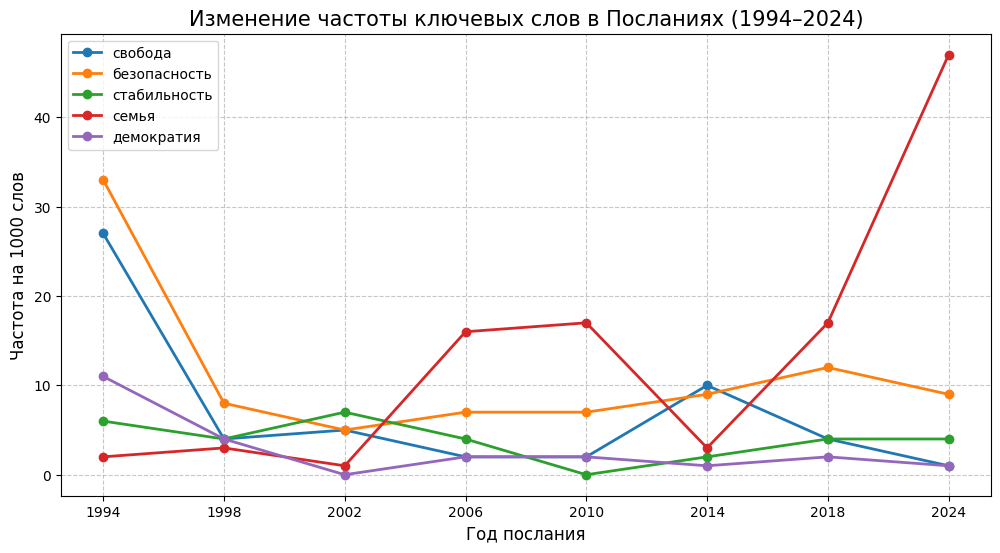

In [73]:
# 3. Визуализация

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Рисуем линию для каждого слова
for word in target_words:
    plt.plot(dynamic_df.columns, dynamic_df.loc[word], marker='o', label=word, linewidth=2)

plt.title('Изменение частоты ключевых слов в Посланиях (1994–2024)', fontsize=15)
plt.xlabel('Год послания', fontsize=12)
plt.ylabel('Частота на 1000 слов', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### 4.3. Поиск слов-маркеров
Часто самое интересное скрывается не в топе общих слов (таких как «государство» или «развитие»), а в словах, которые характерны **только для одного периода**. 

Давайте найдем уникальные слова для 1994 и 2024 годов. Это слова, которые имеют значимую частоту в один год и отсутствуют (равны 0) в другие.

In [77]:
# 1. Выбираем год, который нас интересует
target = '1994'

# 2. Берем все колонки, кроме целевой
other_years = df_rel.columns.drop(target)

# 3. Находим слова, которые в другие годы не встречались (сумма по строке == 0)
unique_lemmas_mask = df_rel[other_years].sum(axis=1) == 0

# 4. Выводим результат для целевого года, где маска сработала
unique = df_rel[unique_lemmas_mask][target].sort_values(ascending=False)

print(unique.head(15))

# давайте выясним слова-маркеры для Посланий других лет

противоречие        0.9
религиозный         0.8
1993                0.8
межнациональный     0.7
меньшинство         0.6
национальность      0.6
наносить            0.5
сбс                 0.5
безработица         0.4
многопартийность    0.3
формула             0.3
конфессия           0.3
церковь             0.3
межрелигиозный      0.3
госбюджет           0.3
Name: 1994, dtype: float64


In [79]:
for year in df_rel.columns:
    target = year
    other_years = df_rel.columns.drop(target)
    unique_lemmas_mask = df_rel[other_years].sum(axis=1) == 0
    unique = df_rel[unique_lemmas_mask][target].sort_values(ascending=False)
    print(f'Cлова-маркеры в {year}')
    print(unique.head(15), "\n\n")


Cлова-маркеры в 1994
противоречие        0.9
религиозный         0.8
1993                0.8
межнациональный     0.7
меньшинство         0.6
национальность      0.6
наносить            0.5
сбс                 0.5
безработица         0.4
многопартийность    0.3
формула             0.3
конфессия           0.3
церковь             0.3
межрелигиозный      0.3
госбюджет           0.3
Name: 1994, dtype: float64 


Cлова-маркеры в 1998
1998                 2.3
1997                 2.1
трансферт            0.7
упорядочение         0.5
доходность           0.5
заимствование        0.5
живой                0.5
злоупотребление      0.5
собираемость         0.5
навязывать           0.4
антикоррупционный    0.4
дифференциация       0.4
статистика           0.4
урегулировать        0.4
сми                  0.3
Name: 1998, dtype: float64 


Cлова-маркеры в 2002
перепись            1.3
чучело              0.5
судебно-правовой    0.5
надзирать           0.5
дееспособный        0.5
бандит              0.

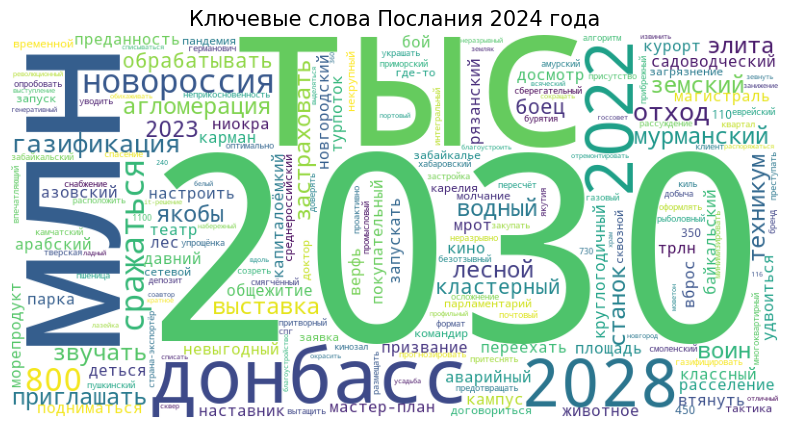

In [86]:
# from wordcloud import WordCloud
# import matplotlib.pyplot as plt

# 1. Выбираем данные
data = unique.to_dict()

# 2. Настраиваем облако
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(data)

# 3. Визуализация
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off') # убираем оси с цифрами
plt.title('Ключевые слова Послания 2024 года', fontsize=15)
plt.show()

#### 4.4 Анализ устойчивых словосочетаний (биграммы и триграммы)
Часто смысл текста заложен не в отдельных словах, а в их устойчивых сочетаниях. Для их поиска мы используем концепцию N-грамм — последовательностей из $n$ элементов.
* Биграммы ($n=2$) позволяют увидеть устойчивые пары (например, «рыночная экономика», «социальная сфера»).
* Триграммы ($n=3$) помогают выявить более сложные идеологемы (например, «великая отечественная война»).

Мы будем строить N-граммы на основе лемматизированного текста. Это позволит нам объединить разные формы одного и того же сочетания (например, «новым проектам» и «нового проекта») в одну сущность, что значительно повысит точность нашего частотного анализа.

In [ ]:
# from collections import Counter
# import pandas as pd

def generate_ngrams(tokens, n):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-(n-1))]

`range(len(tokens)-(n-1))` — центральная часть функции. Когда мы идем по списку слов «окном» определенного размера, мы должны остановиться чуть раньше конца списка, чтобы это окно не «вывалилось» за его пределы. 

Например, если у нас 10 слов и мы ищем триграммы ($n=3$), наше последнее окно начнется на 8-м слове и захватит 8-е, 9-е и 10-е. Если мы попробуем начать окно на 9-м слове, нам просто не хватит элементов для полноценной цепочки. Формула -(n-1) как раз гарантирует, что цикл завершится ровно тогда, когда для последнего окна еще хватает слов.

`tokens[i:i+n]` — механизм среза. На каждой итерации цикла переменная i указывает на начало окна, а i+n — на его конец.

`" ".join(...)` — срезы возвращают списки слов, например `['социальная', 'сфера']`. Работать с нагромождением мелких списков неудобно, поэтому мы превращаем их в обычные строки, склеивая слова через пробел.

In [88]:
def tokenize_corpus(corpus_dict):
    full_results = {}
    
    for year, text in corpus_dict.items():
        substrings = tokenize(text)
        tokens = [substring.text.lower() for substring in substrings]
        
        clean_lemmas = []
        for word in tokens:
            lemma = morph.parse(word)[0].normal_form
            
            if lemma not in stop_words and len(lemma) > 2:
                clean_lemmas.append(lemma)
        
        full_results[year] = clean_lemmas
        
    return full_results

texts_by_year = tokenize_corpus(corpus)

In [91]:
all_years_bigrams = {}

for year in ['1994', '1998', '2002', '2006', '2010', '2014', '2018', '2024']:
    year_lemmas = texts_by_year[year] 
    
    # Генерируем биграммы
    year_bigrams = generate_ngrams(year_lemmas, 2)
    
    # Считаем их и сохраняем в словарь
    all_years_bigrams[year] = Counter(year_bigrams)

# 2. Создаем общий DataFrame
df_ngrams = pd.DataFrame(all_years_bigrams)

# 3. Заполняем пустоты нулями (если биграмма была в 2024, но не в 1994)
df_ngrams = df_ngrams.fillna(0).astype(int).sort_values(by='1994', ascending=False)

df_ngrams.head(15)

,1994,1998,2002,2006,2010,2014,2018,2024
российский федерация,43,25,6,3,3,2,5,6
государственный власть,24,5,3,3,0,0,1,0
федеральный собрание,23,13,7,5,2,2,32,4
субъект федерация,19,8,5,4,2,3,0,13
орган государственный,18,6,2,1,0,0,1,0
федеральный власть,17,3,3,0,0,0,0,0
право человек,15,3,0,1,0,1,0,0
российский государство,15,1,1,1,0,1,1,0
местный самоуправление,14,16,13,3,2,0,2,0
гражданский общество,13,14,1,1,2,0,2,2


In [92]:
for year in df_ngrams.columns:
    target = year
    other_years = df_ngrams.columns.drop(target)
    unique_lemmas_mask = df_ngrams[other_years].sum(axis=1) == 0
    unique = df_ngrams[unique_lemmas_mask][target].sort_values(ascending=False)
    print(f'Биграммы-маркеры в {year}')
    print(unique.head(15), "\n\n")

Биграммы-маркеры в 1994
укрепление российский        10
экономический механизм        6
рыночный преобразование       6
социальный защита             6
государство снг               6
организовать преступность     5
рыночный реформа              5
область право                 5
цена реформа                  5
межнациональный конфликт      4
власть регион                 4
декабрь 1993                  4
свобода человек               4
новый независимый             4
новый закон                   4
Name: 1994, dtype: int64 


Биграммы-маркеры в 1998
экономический оборот        8
государственный служащий    6
участник экономический      6
финансовый стабилизация     6
неплатёж предприятие        5
субъект рынок               5
власть общество             5
подъём страна               5
либерализация экономика     5
государственный нужда       4
бюджет 1999                 4
мировой финансовый          4
живой деньга                4
стратегия подъём            4
роль государство        

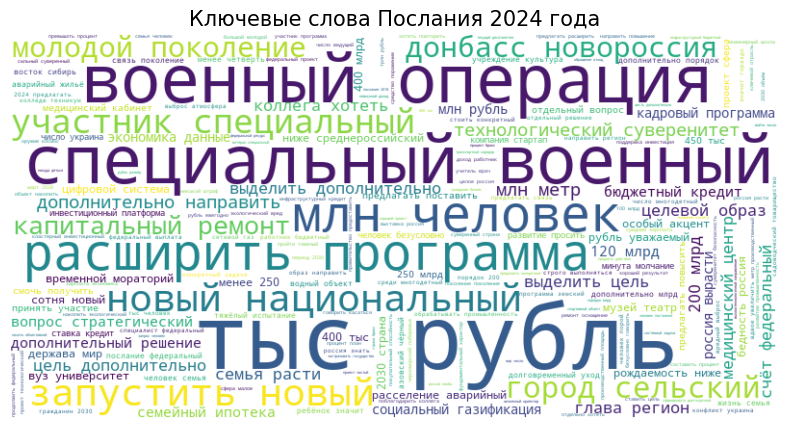

In [94]:
# 1. Выбираем данные
data = unique.to_dict()

# 2. Настраиваем облако
# Параметр font_path важен для корректного отображения кириллицы
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(data)

# 3. Визуализация
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # убираем оси с цифрами
plt.title('Ключевые слова Послания 2024 года', fontsize=15)
plt.show()

#### 4.5 Оценка лексического разнообразия
Стал ли язык официальных обращений более сухим и шаблонным за последние 30 лет? Чтобы ответить на этот вопрос, мы вычислим коэффициент **TTR (Type-Token Ratio)**.

**TTR = (Число уникальных лемм / Общее число лемм) * 100%**

*Высокий TTR* говорит о богатом словарном запасе и низкой повторяемости слов. 
*Низкий TTR* указывает на обилие речевых штампов и повторов.

In [95]:
ttr_results = {}

for year in df.columns:
    # Общее количество слов (сумма по столбцу)
    total_tokens = df[year].sum()
    
    # Количество уникальных слов (где частота > 0)
    unique_types = len(df[df[year] > 0])
    
    # Считаем TTR в процентах
    ttr = (unique_types / total_tokens) * 100
    ttr_results[year] = round(ttr, 2)

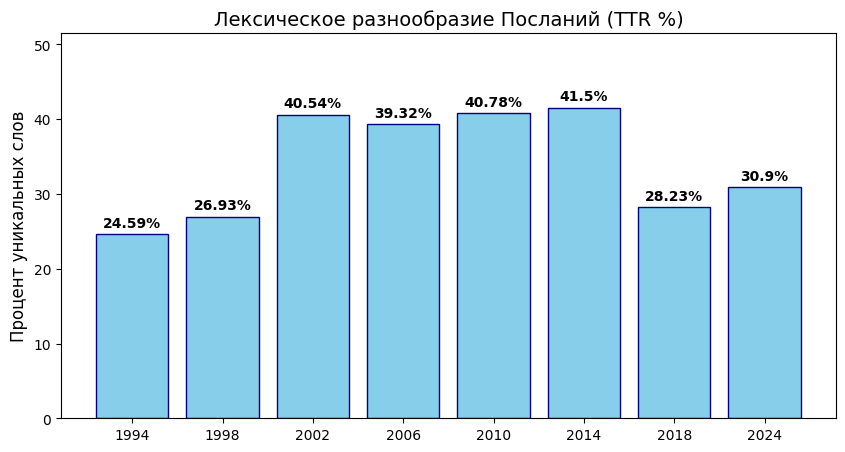

In [96]:
# Визуализация результатов
plt.figure(figsize=(10, 5))
years = list(ttr_results.keys())
values = list(ttr_results.values())

plt.bar(years, values, color='skyblue', edgecolor='navy')
plt.title('Лексическое разнообразие Посланий (TTR %)', fontsize=14)
plt.ylabel('Процент уникальных слов', fontsize=12)
plt.ylim(0, max(values) + 10) # Делаем запас сверху для наглядности

# Добавляем подписи значений над столбцами
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')

plt.show()

### Bonus! Морфологический профиль: Алиса против канцелярита

В лингвистике и стилометрии тексты часто сравнивают не по конкретным словам, а по их грамматике. 
* **Официально-деловой стиль** (Послания): много существительных (особенно отглагольных — *«обеспечение», «развитие»*) и длинных цепочек зависимых слов.
* **Художественный текст** («Алиса в Стране чудес»): опирается на глаголы, местоимения и наречия, диалогичен.

Давайте проверим эту гипотезу с помощью `pymorphy3`. Мы извлечем части речи (POS — Part of Speech) из Послания 2024 года и из фрагмента про Алису, а затем сравним их распределение в процентах.

In [97]:
import numpy as np

# Словарь для перевода тегов pymorphy на человеческий язык
pos_translation = {
    'NOUN': 'Существительные',
    'VERB': 'Глаголы',
    'INFN': 'Глаголы (инф.)',
    'ADJF': 'Прилагательные',
    'ADVB': 'Наречия',
    'NPRO': 'Местоимения',
    'PREP': 'Предлоги',
    'CONJ': 'Союзы'
}

In [98]:
# Функция для подсчета долей частей речи в тексте
def get_pos_distribution(text):
    substrings = tokenize(text)
    pos_counts = Counter()
    
    for substring in substrings:
        parsed = morph.parse(substring.text)[0]
        pos = parsed.tag.POS
        
        # Pymorphy разделяет глаголы в личных формах и инфинитивы, объединим их для простоты
        if pos == 'INFN':
            pos = 'VERB'
            
        if pos: # Если часть речи определена
            pos_counts[pos] += 1
            
    # Переводим в проценты
    total_words = sum(pos_counts.values())
    pos_pct = {pos: (count / total_words) * 100 for pos, count in pos_counts.items()}
    return pos_pct

In [99]:
# Получаем распределение
pos_alice = get_pos_distribution(alice_text)
pos_poslanie = get_pos_distribution(corpus['2024'])

# Выбираем 5 частей речи для сравнения
target_pos = ['NOUN', 'VERB', 'ADJF', 'NPRO', 'ADVB']
labels = [pos_translation[pos] for pos in target_pos]

alice_values = [pos_alice.get(pos, 0) for pos in target_pos]
poslanie_values = [pos_poslanie.get(pos, 0) for pos in target_pos]

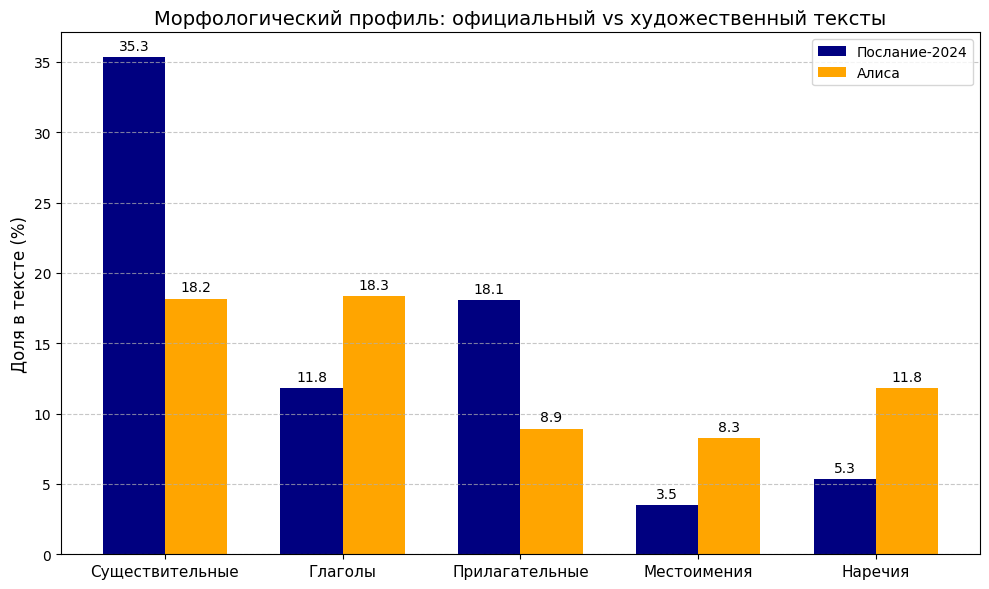

In [100]:
# --- Строим парный столбчатый график ---
x = np.arange(len(labels))
width = 0.35  # Ширина столбцов

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, poslanie_values, width, label='Послание-2024', color='navy')
rects2 = ax.bar(x + width/2, alice_values, width, label='Алиса', color='orange')

ax.set_ylabel('Доля в тексте (%)', fontsize=12)
ax.set_title('Морфологический профиль: официальный vs художественный тексты', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()

# Добавляем цифры над столбцами
ax.bar_label(rects1, fmt='%.1f', padding=3)
ax.bar_label(rects2, fmt='%.1f', padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Документация к используемым библиотекам:
* razdel: https://github.com/natasha/razdel
* pymorphy3: https://pymorphy3.readthedocs.io/
* nltk: https://www.nltk.org/
* regex: https://pypi.org/project/regex/ 
* pandas: https://pandas.pydata.org/docs/
* matplotlib: https://matplotlib.org/stable/contents.html

### Полезное
* Интерактивный тренажер регулярных выражений: https://regex101.com/
* Система граммем словаря OpenCorpora: https://opencorpora.org/dict.php?act=gram
* Фридл Д. - Регулярные выражения